In [ ]:
# prepare Roost-formatted dataset
import pandas as pd
from pymatgen.core import Composition

df = pd.read_csv("materiae_All_Labelled_withSOC_with_Composition_Vectors.csv")

def formula_to_dict(formula):
    return Composition(formula).as_dict()

df["composition_dict"] = df["formula"].apply(formula_to_dict)
df = df[["composition_dict", "is_topological"]]
df.columns = ["composition", "label"]
df.to_json("roost_dataset.json", orient="records")
print("✅ Saved Roost-formatted dataset.")

✅ Saved Roost-formatted dataset.


In [ ]:
import torch
import torch.nn as nn

MAX_Z = 118  

class RoostModel(nn.Module):
    def __init__(self, emb_dim=128, hidden_dim=256):
        super().__init__()

        self.embedding = nn.Embedding(MAX_Z, emb_dim)
        self.attention = nn.MultiheadAttention(embed_dim=emb_dim, num_heads=4, batch_first=True)

        self.predictor = nn.Sequential(
            nn.Linear(emb_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Linear(hidden_dim//2, 1),
            nn.Sigmoid()
        )

    def forward(self, elements, counts):
        x = self.embedding(elements)                         # (batch, n, emb)
        x = x * counts.unsqueeze(-1)                         # weigh by fractional amounts
        x, _ = self.attention(x, x, x)                       # learn interactions
        x = x.sum(dim=1)                                     # pool
        return self.predictor(x).squeeze(1)
import torch
from torch.utils.data import Dataset, DataLoader
from pymatgen.core import Composition

class RoostDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __getitem__(self, idx):
        comp = Composition(self.df.iloc[idx]["composition"])
        elements = torch.tensor([el.Z for el in comp.elements])
        counts = torch.tensor([comp[el] / comp.num_atoms for el in comp.elements])
        label = torch.tensor(float(self.df.iloc[idx]["label"]))
        return elements, counts, label

    def __len__(self):
        return len(self.df)

dataset = RoostDataset(df)
train_loader = DataLoader(dataset, batch_size=64, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))


In [ ]:
!pip install git+https://github.com/CompRhys/roost.git


  Cloning https://github.com/CompRhys/roost.git to /tmp/pip-req-build-e1zqy414
  Running command git clone --filter=blob:none --quiet https://github.com/CompRhys/roost.git /tmp/pip-req-build-e1zqy414
  Resolved https://github.com/CompRhys/roost.git to commit aaabc34d6ee6ac788e36f1c759c0582a997ea9b9
  Preparing metadata (setup.py) ... done
  Created wheel for roost: filename=roost-0.0.2-py3-none-any.whl size=16128 sha256=24d45915cfe60dff10bdc9155c40e28c53df11075a37986dcbe0dc0799b65899
  Stored in directory: /tmp/pip-ephem-wheel-cache-4vevp2ho/wheels/7a/8f/ef/8d572f933d2b75912b8a559f2802dbb52b7ada3addd8717031
Successfully built roost


In [ ]:
!pip install --quiet dgl
!pip install --quiet git+https://github.com/CompRhys/roost.git


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 118.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import pandas as pd

df = pd.read_csv("materiae_All_Labelled_withSOC_with_Composition_Vectors.csv")
df_roost = df[["formula", "is_topological"]].copy()
df_roost.to_csv("roost_dataset.csv", index=False)

print("✅ Saved roost_dataset.csv with", len(df_roost), "samples")


✅ Saved roost_dataset.csv with 22245 samples


In [ ]:
# split dataset into train/val/test sets
from sklearn.model_selection import train_test_split

df = pd.read_csv("roost_dataset.csv")

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["is_topological"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["is_topological"], random_state=42)

train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)

print("✅ Dataset Split:")
print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))


✅ Dataset Split:
Train: 15571 Val: 3337 Test: 3337


In [ ]:
import roost
print("Roost imported successfully ✅")


Roost imported successfully ✅


In [ ]:
pip install torch-geometric


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 73.8 MB/s eta 0:00:00


In [ ]:
pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 28.6 MB/s eta 0:00:00


In [ ]:

import torch
import torch.nn as nn
import pandas as pd
from pymatgen.core import Composition
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from torch.utils.data import Dataset, DataLoader

from torch_geometric.nn import Set2Set   # ✅ IMPORTANT FIX


In [ ]:
# Roost Model optimization with Optuna

import torch
import torch.nn as nn
import pandas as pd
from pymatgen.core import Composition
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from torch.utils.data import Dataset, DataLoader
import optuna


df = pd.read_csv("materiae_All_Labelled_withSOC_with_Composition_Vectors.csv")

def formula_to_dict(formula):
    return Composition(formula).as_dict()

df["composition_dict"] = df["formula"].apply(formula_to_dict)
df = df[["composition_dict", "is_topological"]]
df.columns = ["composition", "label"]

# Stratified split
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")



class RoostDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __getitem__(self, idx):
        comp = Composition(self.df.iloc[idx]["composition"])
        elements = torch.tensor([el.Z for el in comp.elements], dtype=torch.long)
        counts = torch.tensor([comp[el] / comp.num_atoms for el in comp.elements], dtype=torch.float32)
        label = torch.tensor(float(self.df.iloc[idx]["label"]), dtype=torch.float32)
        return elements, counts, label

    def __len__(self):
        return len(self.df)


def collate(batch):
    elements, counts, labels = zip(*batch)
    max_len = max(len(e) for e in elements)

    pad_e = torch.zeros(len(elements), max_len, dtype=torch.long)
    pad_c = torch.zeros(len(elements), max_len, dtype=torch.float32)

    for i, (e, c) in enumerate(zip(elements, counts)):
        pad_e[i, :len(e)] = e
        pad_c[i, :len(c)] = c

    labels = torch.stack(labels)
    return pad_e, pad_c, labels


train_loader = DataLoader(RoostDataset(train_df), batch_size=64, shuffle=True, collate_fn=collate)
val_loader   = DataLoader(RoostDataset(val_df), batch_size=64, shuffle=False, collate_fn=collate)
test_loader  = DataLoader(RoostDataset(test_df), batch_size=64, shuffle=False, collate_fn=collate)




MAX_Z = 118

class RoostModel(nn.Module):
    def __init__(self, emb_dim=128, hidden_dim=256, num_heads=4, num_att_layers=2, dropout=0.2):
        super().__init__()

        self.embedding = nn.Embedding(MAX_Z, emb_dim)

        self.att_layers = nn.ModuleList([
            nn.MultiheadAttention(emb_dim, num_heads, batch_first=True)
            for _ in range(num_att_layers)
        ])

        self.predictor = nn.Sequential(
            nn.Linear(emb_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1),
            nn.Sigmoid()
        )

    def masked_mean(self, x, counts):
        mask = (counts > 0).unsqueeze(-1).float()
        x = x * mask
        return x.sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)

    def forward(self, elements, counts):
        x = self.embedding(elements)
        x = x * counts.unsqueeze(-1)

        for att in self.att_layers:
            x, _ = att(x, x, x)

        x = self.masked_mean(x, counts)
        return self.predictor(x).squeeze(1)




device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def evaluate(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for e, c, l in loader:
            e, c, l = e.to(device), c.to(device), l.to(device)
            p = model(e, c)
            preds.append(p.cpu())
            labels.append(l.cpu())
    preds = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()
    acc = accuracy_score(labels, (preds > 0.5).astype(int))
    auc = roc_auc_score(labels, preds)
    return acc, auc




def objective(trial):
    emb_dim     = trial.suggest_categorical("emb_dim", [96, 128, 192, 256])
    num_heads   = trial.suggest_categorical("num_heads", [2, 4, 8])
    num_layers  = trial.suggest_int("num_att_layers", 1, 4)
    hidden_dim  = trial.suggest_categorical("hidden_dim", [128, 256, 384, 512])
    dropout     = trial.suggest_float("dropout", 0.05, 0.35)
    lr          = trial.suggest_loguniform("lr", 1e-4, 3e-3)

    model = RoostModel(
        emb_dim=emb_dim,
        hidden_dim=hidden_dim,
        num_heads=num_heads,
        num_att_layers=num_layers,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    for epoch in range(6): 
        model.train()
        for e, c, l in train_loader:
            e, c, l = e.to(device), c.to(device), l.to(device)
            optimizer.zero_grad()
            loss = criterion(model(e, c), l)
            loss.backward()
            optimizer.step()

    _, val_auc = evaluate(model, val_loader)
    return val_auc


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("\n===== Best Hyperparameters Found =====")
print(study.best_params)
print("Best Val AUC:", study.best_value)


best = study.best_params

model = RoostModel(
    emb_dim=best["emb_dim"],
    hidden_dim=best["hidden_dim"],
    num_heads=best["num_heads"],
    num_att_layers=best["num_att_layers"],
    dropout=best["dropout"]
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=best["lr"])
criterion = nn.BCELoss()

for epoch in range(25):
    model.train()
    for e, c, l in train_loader:
        e, c, l = e.to(device), c.to(device), l.to(device)
        optimizer.zero_grad()
        loss = criterion(model(e, c), l)
        loss.backward()
        optimizer.step()

    train_acc, train_auc = evaluate(model, train_loader)
    val_acc, val_auc = evaluate(model, val_loader)
    print(f"Epoch {epoch+1:02d} | Train AUC: {train_auc:.3f}, Val AUC: {val_auc:.3f}")

test_acc, test_auc = evaluate(model, test_loader)
print("\n===== FINAL TEST PERFORMANCE =====")
print(f"Test Accuracy: {test_acc:.3f}")
print(f"Test AUC:      {test_auc:.3f}")


[I 2025-11-06 11:42:41,650] A new study created in memory with name: no-name-a1763448-1e63-499f-a586-1a44d31bb094


Train: 15571, Val: 3337, Test: 3337


/tmp/ipython-input-3252635328.py:148: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr          = trial.suggest_loguniform("lr", 1e-4, 3e-3)
[I 2025-11-06 11:43:00,972] Trial 0 finished with value: 0.9532013901503331 and parameters: {'emb_dim': 128, 'num_heads': 4, 'num_att_layers': 1, 'hidden_dim': 128, 'dropout': 0.17419162380214012, 'lr': 0.001152175752935779}. Best is trial 0 with value: 0.9532013901503331.
/tmp/ipython-input-3252635328.py:148: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr          = trial.suggest_loguniform("lr", 1e-4, 3e-3)
[I 2025-11-06 11:43:20,065] Trial 1 finished with value: 0.9514706886941996 and parameters: {'emb_dim': 256, 'num_heads': 


===== Best Hyperparameters Found =====
{'emb_dim': 256, 'num_heads': 2, 'num_att_layers': 1, 'hidden_dim': 256, 'dropout': 0.10414787174085172, 'lr': 0.00027926545984950846}
Best Val AUC: 0.9549514984404668
Epoch 01 | Train AUC: 0.934, Val AUC: 0.933
Epoch 02 | Train AUC: 0.945, Val AUC: 0.942
Epoch 03 | Train AUC: 0.951, Val AUC: 0.946
Epoch 04 | Train AUC: 0.955, Val AUC: 0.948
Epoch 05 | Train AUC: 0.957, Val AUC: 0.952
Epoch 06 | Train AUC: 0.961, Val AUC: 0.953
Epoch 07 | Train AUC: 0.963, Val AUC: 0.952
Epoch 08 | Train AUC: 0.964, Val AUC: 0.952
Epoch 09 | Train AUC: 0.965, Val AUC: 0.953
Epoch 10 | Train AUC: 0.964, Val AUC: 0.955
Epoch 11 | Train AUC: 0.967, Val AUC: 0.953
Epoch 12 | Train AUC: 0.968, Val AUC: 0.954
Epoch 13 | Train AUC: 0.965, Val AUC: 0.953
Epoch 14 | Train AUC: 0.969, Val AUC: 0.955
Epoch 15 | Train AUC: 0.970, Val AUC: 0.953
Epoch 16 | Train AUC: 0.971, Val AUC: 0.951
Epoch 17 | Train AUC: 0.972, Val AUC: 0.953
Epoch 18 | Train AUC: 0.972, Val AUC: 0.951


In [ ]:
model = RoostModel(
    emb_dim=best["emb_dim"],
    hidden_dim=best["hidden_dim"],
    num_heads=best["num_heads"],
    num_att_layers=best["num_att_layers"],
    dropout=best["dropout"]
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=best["lr"])


In [ ]:
# Final Training with Best Hyperparameters
best = study.best_params

model = RoostModel(
    emb_dim=best["emb_dim"],
    hidden_dim=best["hidden_dim"],
    num_heads=best["num_heads"],
    num_att_layers=best["num_att_layers"],
    dropout=best["dropout"]
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=best["lr"])
criterion = nn.BCELoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)

best_val_auc = 0
wait = 0
patience = 300

for epoch in range(100):
    model.train()
    for e, c, l in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(e.to(device), c.to(device)), l.to(device))
        loss.backward()
        optimizer.step()

    train_acc, train_auc = evaluate(model, train_loader)
    val_acc, val_auc = evaluate(model, val_loader)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Acc: {train_acc:.3f}, Train AUC: {train_auc:.3f} | "
        f"Val Acc: {val_acc:.3f}, Val AUC: {val_auc:.3f}"
    )

    scheduler.step(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        wait = 0
        best_model_state = model.state_dict().copy()
    else:
        wait += 1
        if wait >= patience:
            print(f"\n⏹️ Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_model_state)


Epoch 01 | Train Acc: 0.899, Train AUC: 0.945 | Val Acc: 0.894, Val AUC: 0.944
Epoch 02 | Train Acc: 0.905, Train AUC: 0.953 | Val Acc: 0.897, Val AUC: 0.947
Epoch 03 | Train Acc: 0.909, Train AUC: 0.957 | Val Acc: 0.904, Val AUC: 0.951
Epoch 04 | Train Acc: 0.913, Train AUC: 0.960 | Val Acc: 0.907, Val AUC: 0.953
Epoch 05 | Train Acc: 0.915, Train AUC: 0.961 | Val Acc: 0.906, Val AUC: 0.953
Epoch 06 | Train Acc: 0.917, Train AUC: 0.964 | Val Acc: 0.908, Val AUC: 0.953
Epoch 07 | Train Acc: 0.917, Train AUC: 0.965 | Val Acc: 0.909, Val AUC: 0.954
Epoch 08 | Train Acc: 0.919, Train AUC: 0.967 | Val Acc: 0.909, Val AUC: 0.954
Epoch 09 | Train Acc: 0.921, Train AUC: 0.969 | Val Acc: 0.910, Val AUC: 0.954
Epoch 10 | Train Acc: 0.923, Train AUC: 0.971 | Val Acc: 0.907, Val AUC: 0.952
Epoch 11 | Train Acc: 0.924, Train AUC: 0.972 | Val Acc: 0.909, Val AUC: 0.954
Epoch 12 | Train Acc: 0.925, Train AUC: 0.974 | Val Acc: 0.908, Val AUC: 0.954
Epoch 13 | Train Acc: 0.928, Train AUC: 0.975 | Val 

<All keys matched successfully>

In [ ]:
test_acc, test_auc = evaluate(model, test_loader)
print(f"Test Accuracy: {test_acc:.3f}")
print(f"Test AUC:      {test_auc:.3f}")


Test Accuracy: 0.901
Test AUC:      0.936



Confusion Matrix:
[[1954  171]
 [ 160 1052]]


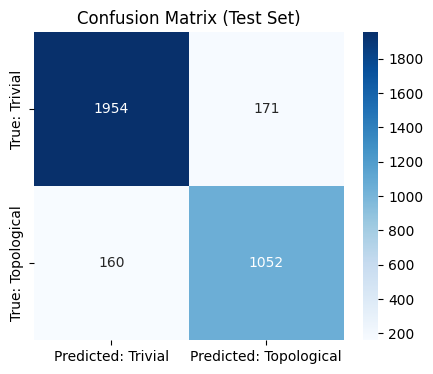


Classification Report:
              precision    recall  f1-score   support

         0.0      0.924     0.920     0.922      2125
         1.0      0.860     0.868     0.864      1212

    accuracy                          0.901      3337
   macro avg      0.892     0.894     0.893      3337
weighted avg      0.901     0.901     0.901      3337



In [ ]:
# Apply on Test Set

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for e, c, l in test_loader:
        p = model(e.to(device), c.to(device))
        all_preds.append(p.cpu().numpy())
        all_labels.append(l.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

binary_preds = (all_preds > 0.5).astype(int)


cm = confusion_matrix(all_labels, binary_preds)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted: Trivial", "Predicted: Topological"],
            yticklabels=["True: Trivial", "True: Topological"])
plt.xlabel("")
plt.ylabel("")
plt.title("Confusion Matrix (Test Set)")
plt.show()


print("\nClassification Report:")
print(classification_report(all_labels, binary_preds, digits=3))


In [ ]:
checkpoint = {
    "model_state": best_model_state,
    "hyperparameters": best
}
torch.save(checkpoint, "roost_best_checkpoint.pt")
print("✅ Saved full model checkpoint → roost_best_checkpoint.pt")


✅ Saved full model checkpoint → roost_best_checkpoint.pt


In [ ]:
# Extract Latent Representations from Trained Model

def get_latent_representations(model, loader):
    model.eval()
    reps = []
    labels = []

    with torch.no_grad():
        for e, c, l in loader:
            e, c = e.to(device), c.to(device)

            # forward up to masked_mean pooling
            x = model.embedding(e)
            x = x * c.unsqueeze(-1)
            for att in model.att_layers:
                x, _ = att(x, x, x)
            x = model.masked_mean(x, c)

            reps.append(x.cpu())
            labels.append(l.cpu())

    reps = torch.cat(reps).numpy()
    labels = torch.cat(labels).numpy()
    return reps, labels


In [ ]:
reps, labels = get_latent_representations(model, test_loader)
print("Latent rep shape:", reps.shape)  # (N, emb_dim)


Latent rep shape: (3337, 256)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 3337 samples in 0.001s...
[t-SNE] Computed neighbors for 3337 samples in 0.211s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3337
[t-SNE] Computed conditional probabilities for sample 2000 / 3337
[t-SNE] Computed conditional probabilities for sample 3000 / 3337
[t-SNE] Computed conditional probabilities for sample 3337 / 3337
[t-SNE] Mean sigma: 0.547402
[t-SNE] KL divergence after 250 iterations with early exaggeration: 72.896942
[t-SNE] KL divergence after 2000 iterations: 1.097120


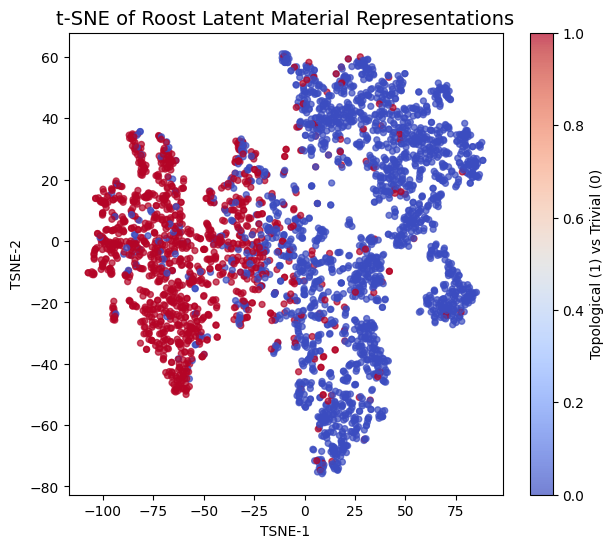

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=2000, verbose=1)
rep_2d = tsne.fit_transform(reps)

plt.figure(figsize=(7,6))
scatter = plt.scatter(rep_2d[:,0], rep_2d[:,1], c=labels, cmap="coolwarm", alpha=0.7, s=18)
plt.title("t-SNE of Roost Latent Material Representations", fontsize=14)
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")
plt.colorbar(scatter, label="Topological (1) vs Trivial (0)")
plt.show()
